In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:

df = pd.read_csv("parkinsons_disease_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (2105, 36)


In [ ]:

df.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,Diet,...,Tremor,Rigidity,Bradykinesia,Posture,SpeechProblems,SleepDisorders,Constipation,Diagnosis,Unnamed: 34,Unnamed: 35
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1,0,0,0,0,0,0,0,NaN,NaN
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,0,1,0,1,0,1,0,1,NaN,NaN
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,1,0,0,0,1,0,1,1,NaN,NaN
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,1,1,1,0,0,0,1,1,NaN,NaN
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,0,0,0,1,0,1,0,0,NaN,NaN


In [ ]:

unnamed_columns = [
    col for col in df.columns
    if col.startswith("Unnamed")
]

df = df.drop(columns=unnamed_columns)

print("Removed columns:", unnamed_columns)
print("New shape:", df.shape)


Removed columns: ['Unnamed: 34', 'Unnamed: 35']
New shape: (2105, 34)


In [ ]:

print("Total missing values:", df.isnull().sum().sum())

missing_values = df.isnull().sum()

if missing_values.sum() > 0:
    print("\nColumns containing missing values:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found.")


Total missing values: 0
No missing values found.


In [ ]:

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (2105, 34)


In [27]:
# Target variable
y = df["Diagnosis"]

# Remove target and PatientID from features
X = df.drop(
    columns=["Diagnosis", "PatientID"],
    errors="ignore"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())


X shape: (2105, 32)
y shape: (2105,)

Columns:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'Diet', 'SleepQuality', 'FamilyHistoryParkinsons', 'BrainInjury', 'Hypertension', 'Diabetes', 'Depression', 'Stroke', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'UPDRS', 'MoCA', 'FunctionalAssessment', 'Tremor', 'Rigidity', 'Bradykinesia', 'Posture', 'SpeechProblems', 'SleepDisorders', 'Constipation']

Target distribution:
Diagnosis
1    1304
0     801
Name: count, dtype: int64


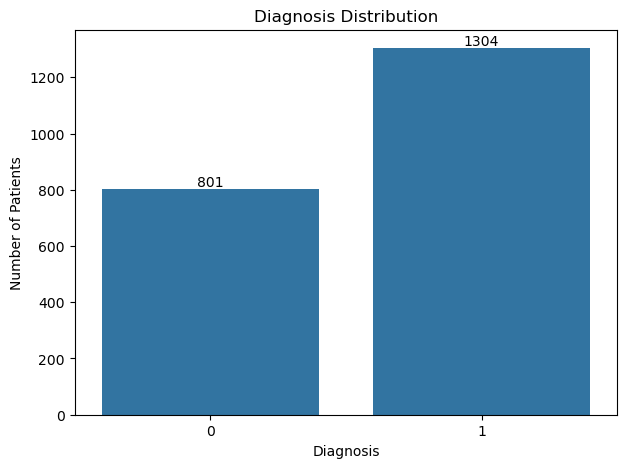

In [28]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x=y
)

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [29]:
# 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)


Training features: (1684, 32)
Testing features : (421, 32)
Training target  : (1684,)
Testing target   : (421,)


In [30]:
#all data convert between 0 and 1.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")


Feature scaling completed!


In [31]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


In [32]:
model

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
model.fit(
    X_train_scaled,
    y_train
)



LogisticRegression(max_iter=1000, random_state=42)

In [35]:
# Class prediction

y_pred = model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred[:20])


First 20 predictions:
[0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1]
